In [489]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tools.tools import *
from tools.bag_to_df import bag_topic_to_dataframe
import pandas as pd
from scipy.spatial.transform import Rotation as R
from tools.signal_properties import compare_signals


%load_ext autoreload
%autoreload 2

REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
# SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_06-11_06_52"
SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_07-09_18_26"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [490]:
print_bag_topics(REAL_BAG_PATH)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

# Read data

In [491]:
# NUCLEUS
nucleus_ins = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/ins")

# Add roll pitch yaw to nucleus ins
quats = nucleus_ins[["quaternion.x", "quaternion.y", "quaternion.z", "quaternion.w"]].values
eulers = R.from_quat(quats).as_euler('xyz', degrees=False)
nucleus_ins["roll"] = eulers[:, 0]
nucleus_ins["pitch"] = eulers[:, 1]
nucleus_ins["yaw"] = eulers[:, 2]

nucleus_alitmeter = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/altimeter")
nucleus_bottomtrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/bottomtrack")
nucleus_magnetometer = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/magnetometer")
nucleus_watertrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/watertrack")

# A50
dvl_a50_position = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_position")
dvl_a50_velocity = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_velocity")

# SIM
sim_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl")
sim_a50 = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl_a50")
sim_gt = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")
sim_ins = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ins")
print("")

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


# Normalize time

Use the first element of ground truth running at 100 Hz as the starting point of time. Topics spawn after some time

In [492]:
# Get t0 of real data
# bagdir = Path(REAL_BAG_PATH)
# with AnyReader([Path(bagdir)]) as reader:
#     t0_real = reader.start_time * 1e-9 # Seconds

imu = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/imu")
t0_real = imu["t"][0]

# Get t0 of simulation
t0_sim = sim_gt["t"].iloc[0]

def set_t0(df: pd.DataFrame, t_0):
    df["t"] -= t_0

# Subtract t0
set_t0(sim_gt, t0_sim)
set_t0(sim_a50, t0_sim)
set_t0(sim_dvl, t0_sim)
set_t0(sim_ins, t0_sim)

set_t0(nucleus_ins, t0_real)
set_t0(nucleus_alitmeter, t0_real)
set_t0(nucleus_bottomtrack, t0_real)
set_t0(nucleus_magnetometer, t0_real)
set_t0(nucleus_watertrack, t0_real)
set_t0(dvl_a50_position, t0_real)
set_t0(dvl_a50_velocity, t0_real)


# Sway Velocity

{'rmse': 0.013680633512566608, 'corr': 0.917968529569573, 'mean_error': 0.001042275066563084, 'kurtosis_diff': 4.160895879464336}
{'rmse': 2.9482503080970335, 'corr': -0.00698246940833837, 'mean_error': 0.3939426389114804, 'kurtosis_diff': 69.98677455323799}


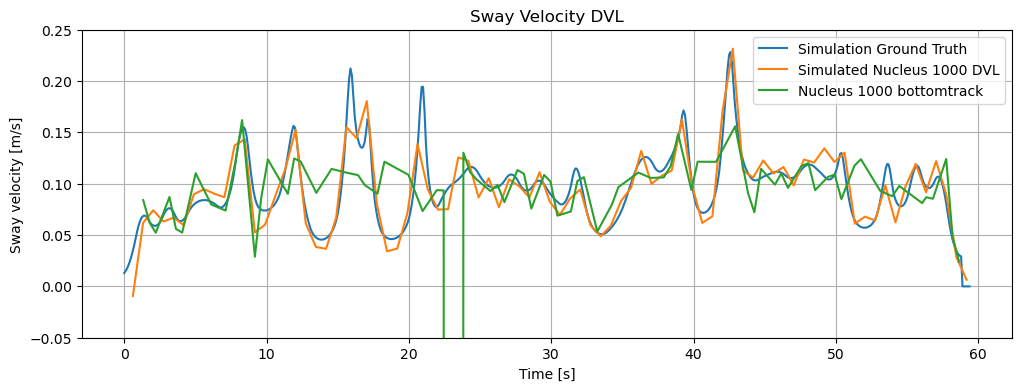

In [493]:
plt.figure(figsize=(12, 4))

# --- GROUND THRUTH ---
plt.plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values, label="Simulation Ground Truth")

# --- SIMULATED NUCLEUS ---
plt.plot(sim_dvl["t"].values, -sim_dvl["velocity.y"].values, label="Simulated Nucleus 1000 DVL")

# --- SIMULATED A50 ---
# plt.plot(sim_a50["t"].values, -sim_a50["velocity.y"].values, label="Simulated DVL-A50")

# --- NUCLEUS BOTTOMTRACK ---
plt.plot(nucleus_bottomtrack["t"].values, nucleus_bottomtrack["dvl_velocity_xyz.x"].values, label="Nucleus 1000 bottomtrack")

# --- NUCLEUS INS ---
# plt.plot(nucleus_ins["t"].values, (nucleus_ins["velocityNucleus.x"].values), label="Nucleus 1000 INS")


# --- DVL-A50 ---
# plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["velocity.x"].values, label="DVL-A50")

plt.title("Sway Velocity DVL")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

comp_simulated = compare_signals(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values,
                        sim_dvl["t"].values, -sim_dvl["velocity.y"].values)

comp_real      = compare_signals(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values,
                        nucleus_bottomtrack["t"].values, nucleus_bottomtrack["dvl_velocity_xyz.x"].values)
print(comp_simulated)
print(comp_real)


In [494]:
# fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# axes[0].plot(sim_dvl["t"].values, -sim_dvl["velocity.y"].values, label="Simulated Nucleus 1000 DVL")
# axes[0].plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values, label="Simulation Ground Truth")
# axes[0].set_title("Simulated DVL vs Ground Truth")
# axes[0].set_ylabel("Sway Velocity [m/s]")
# axes[0].legend()
# axes[0].grid(True)

# axes[1].plot(nucleus_bottomtrack["t"].values, nucleus_bottomtrack["dvl_velocity_xyz.x"].values, label="Nucleus 1000 Bottomtrack")
# axes[1].plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values, label="Simulation Ground Truth")
# axes[1].set_title("Nucleus 1000 Bottomtrack vs Ground Truth")
# axes[1].set_ylabel("Sway Velocity [m/s]")
# axes[1].legend()
# axes[1].set_ylim((-0.05, 0.25))
# axes[1].grid(True)


Diskusjon: Erroren vil forplante seg gjennom rekonstrueringen av signalet

# Position comparison

In [495]:
# First transform raw data similar to what was done when making keypoints
cg_to_dvl = 0.153
xyz_post = np.array([23.69 - cg_to_dvl, 4.5, 0])
rpy_post = np.array([0, 0, -0.55])

xyz = np.column_stack((nucleus_ins["positionFrame.y"].values, -nucleus_ins["positionFrame.x"].values, nucleus_ins["positionFrame.z"].values))
quats = nucleus_ins[["quaternion.x","quaternion.y","quaternion.z","quaternion.w"]].to_numpy(dtype=float)
eul = R.from_quat(quats).as_euler('xyz', degrees=False)
roll, pitch, yaw = eul[:,0], eul[:,1], eul[:,2]

rpy = np.column_stack((roll, pitch, yaw))
xyz_transformed, rpy_transformed = transform_path(xyz_post, rpy_post, xyz, rpy)

t = nucleus_ins["t"].to_numpy()

{'rmse': 0.01103353487781067, 'corr': 0.9953257181956836, 'mean_error': -0.00274948540044603, 'kurtosis_diff': 1.04100320302493}
{'rmse': 0.04497143044273338, 'corr': 0.9999594725055123, 'mean_error': -0.042269134080907766, 'kurtosis_diff': 0.7463155422465912}
{'rmse': 0.012274574855312343, 'corr': 0.972248547976922, 'mean_error': 0.0013343151648501927, 'kurtosis_diff': 2.271743887702505}


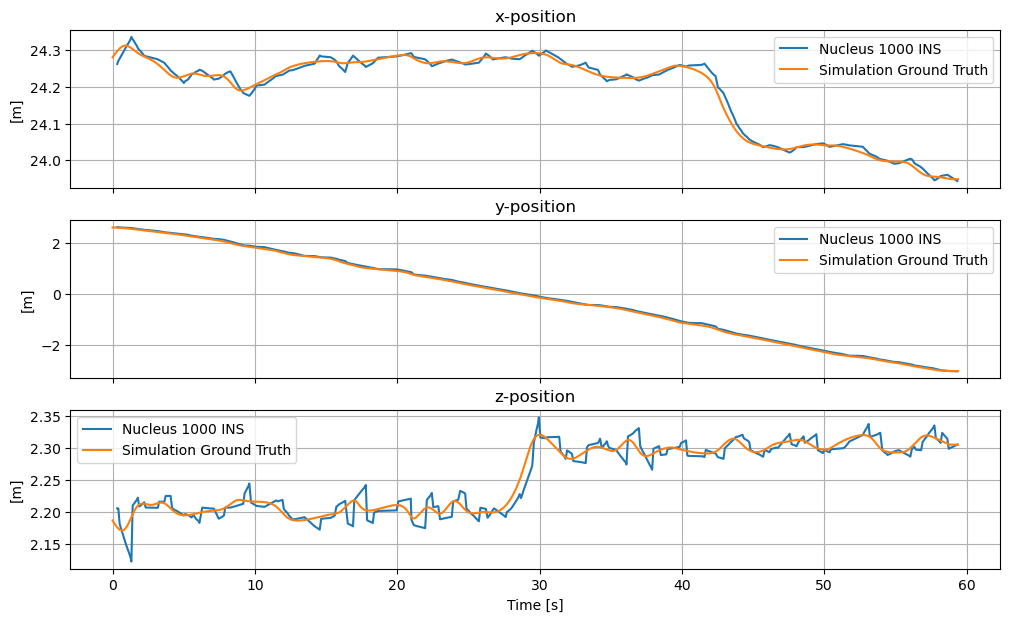

In [496]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t, xyz_transformed[:,0], label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values, label="Simulation Ground Truth")
axes[0].set_title("x-position")
axes[0].set_ylabel("[m]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, xyz_transformed[:,1], label="Nucleus 1000 INS")
axes[1].plot(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values, label="Simulation Ground Truth")
axes[1].set_title("y-position")
axes[1].set_ylabel("[m]")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t, xyz_transformed[:,2], label="Nucleus 1000 INS")
axes[2].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
axes[2].set_title("z-position")
axes[2].set_ylabel("[m]")
axes[2].set_xlabel("Time [s]")
axes[2].legend()
axes[2].grid(True)

comp_x = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values,
                        t, xyz_transformed[:,0])

comp_y = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values,
                        t, xyz_transformed[:,1])

comp_z = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values,
                        t, xyz_transformed[:,2])

print(comp_x)
print(comp_y)
print(comp_z)

# Velocity comparison
Diskuter hvor god banen som simuleres er i forhold til ground trurth

In [497]:
# Transform velocity vector using the same rotation as making the keypoints

xyz_vel = np.column_stack((nucleus_ins["velocityNed.y"].values, -nucleus_ins["velocityNed.x"].values, nucleus_ins["velocityNed.z"].values))

quats = nucleus_ins[["quaternion.x","quaternion.y","quaternion.z","quaternion.w"]].to_numpy(dtype=float)
eul = R.from_quat(quats).as_euler('xyz', degrees=False)
roll, pitch, yaw = eul[:,0], eul[:,1], eul[:,2]


rpy = np.column_stack((roll, pitch, yaw))
xyz_vel_transformed, rpy_transformed = transform_path(np.array([0, 0, 0]), rpy_post, xyz_vel, rpy)

t = nucleus_ins["t"].to_numpy()

{'rmse': 0.024837469488912585, 'corr': 0.5628974297858509, 'mean_error': 0.0035506476436542324, 'kurtosis_diff': 0.08709791192361038}
{'rmse': 0.03328338345735119, 'corr': 0.40986333790346374, 'mean_error': 0.0018021548188696561, 'kurtosis_diff': 0.8388629631872209}
{'rmse': 0.02442500998704315, 'corr': 0.19990217568261634, 'mean_error': 0.0013479224412837236, 'kurtosis_diff': 2.5350898573153318}


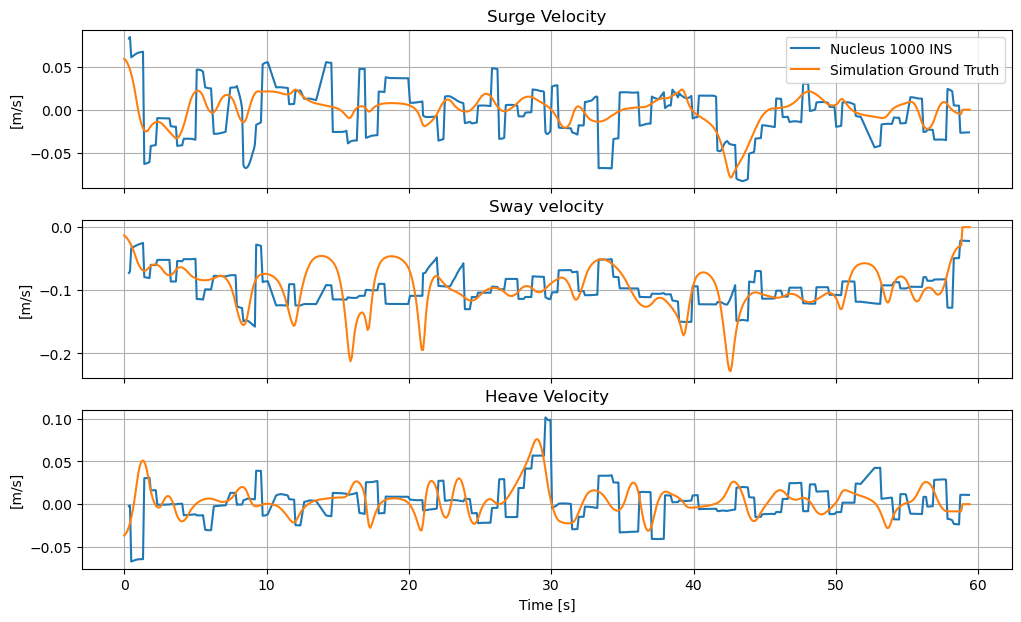

In [498]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t, xyz_vel_transformed[:,0], label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["twist.twist.linear.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Surge Velocity")
axes[0].set_ylabel("[m/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, xyz_vel_transformed[:,1])
axes[1].plot(sim_gt["t"].values, sim_gt["twist.twist.linear.y"].values)
axes[1].set_title("Sway velocity")
axes[1].set_ylabel("[m/s]")
axes[1].grid(True)


axes[2].plot(t, xyz_vel_transformed[:,2])
axes[2].plot(sim_gt["t"].values, sim_gt["twist.twist.linear.z"].values)
axes[2].set_title("Heave Velocity")
axes[2].set_ylabel("[m/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_surge = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.x"].values,
                        t, xyz_vel_transformed[:,0])

comp_sway = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.y"].values,
                        t, xyz_vel_transformed[:,1])

comp_heave = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.z"].values,
                        t, xyz_vel_transformed[:,2])

print(comp_surge)
print(comp_sway)
print(comp_heave)

# Velocity comparison using Nucleus frame directly

{'rmse': 0.023453320606163452, 'corr': 0.561123047130853, 'mean_error': -0.0020866692660226954, 'kurtosis_diff': 0.036698541107269556}
{'rmse': 0.033410027472986645, 'corr': 0.4142724778191395, 'mean_error': 0.0019573737397702872, 'kurtosis_diff': 0.7917995094128369}
{'rmse': 0.02488852381197597, 'corr': 0.195487092625699, 'mean_error': -0.0006134559268764302, 'kurtosis_diff': 2.9126005795704204}


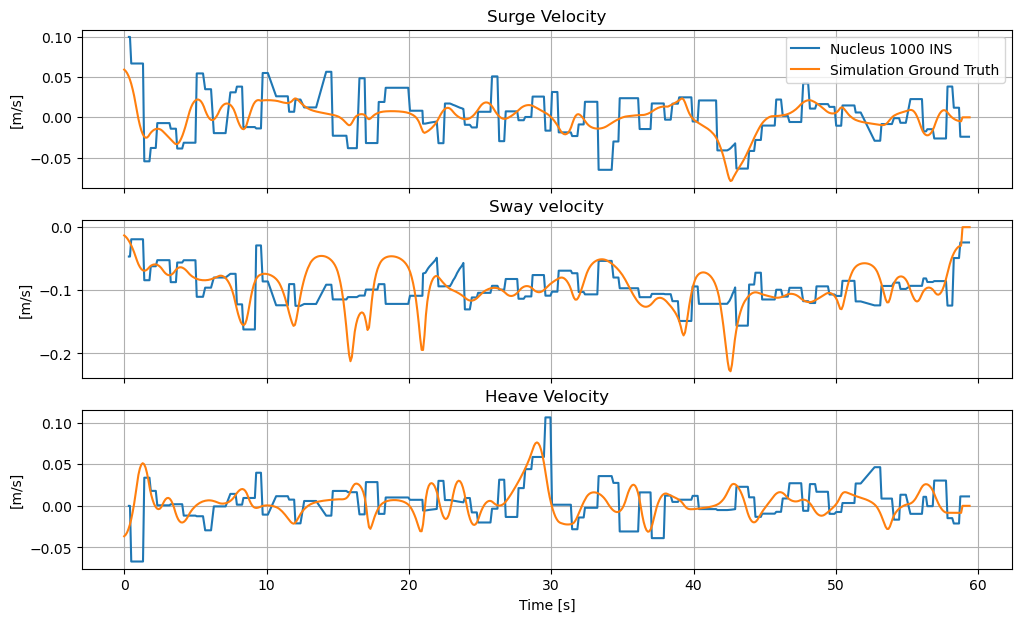

In [499]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values, label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["twist.twist.linear.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Surge Velocity")
axes[0].set_ylabel("[m/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)
axes[1].plot(sim_gt["t"].values, sim_gt["twist.twist.linear.y"].values)
axes[1].set_title("Sway velocity")
axes[1].set_ylabel("[m/s]")
axes[1].grid(True)


axes[2].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)
axes[2].plot(sim_gt["t"].values, sim_gt["twist.twist.linear.z"].values)
axes[2].set_title("Heave Velocity")
axes[2].set_ylabel("[m/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_surge = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.x"].values,
                        nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values)

comp_sway = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.y"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)

comp_heave = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.z"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)

print(comp_surge)
print(comp_sway)
print(comp_heave)

# Angular velocity comparison

{'rmse': 0.024837469488912585, 'corr': 0.5628974297858509, 'mean_error': 0.0035506476436542324, 'kurtosis_diff': 0.08709791192361038}
{'rmse': 0.03328338345735119, 'corr': 0.40986333790346374, 'mean_error': 0.0018021548188696561, 'kurtosis_diff': 0.8388629631872209}
{'rmse': 0.02442500998704315, 'corr': 0.19990217568261634, 'mean_error': 0.0013479224412837236, 'kurtosis_diff': 2.5350898573153318}


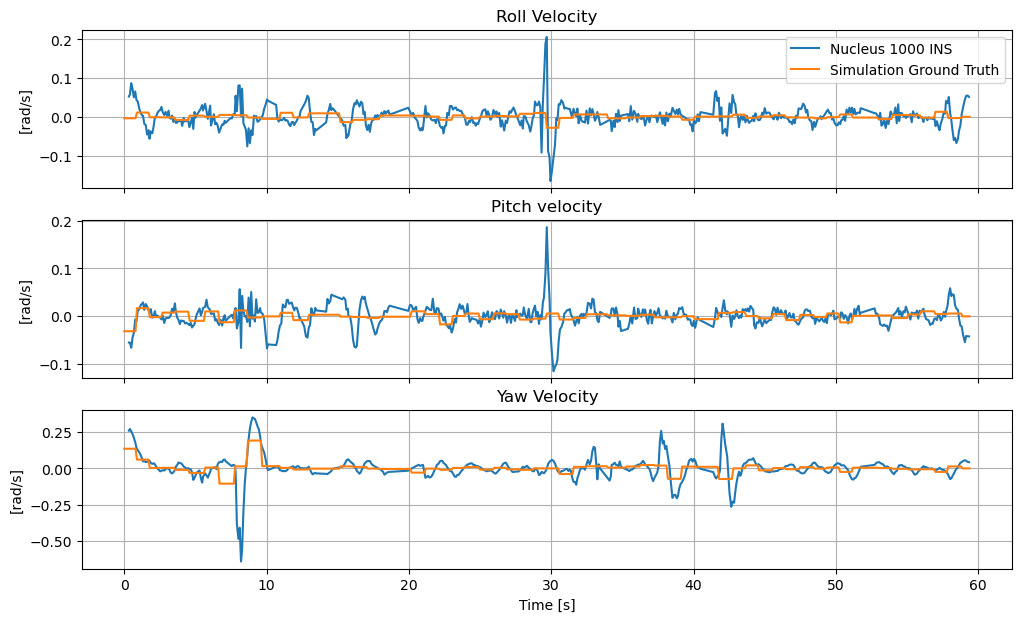

In [ ]:

rpy_vel = np.column_stack((np.deg2rad(nucleus_ins["turnRate.x"].values), np.deg2rad(nucleus_ins["turnRate.z"].values), np.deg2rad(-nucleus_ins["turnRate.y"].values)))


fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t, rpy_vel[:,0], label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Roll Velocity")
axes[0].set_ylabel("[rad/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, rpy_vel[:,1])
axes[1].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.y"].values)
axes[1].set_title("Pitch velocity")
axes[1].set_ylabel("[rad/s]")
axes[1].grid(True)


axes[2].plot(t, rpy_vel[:,2])
axes[2].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.z"].values)
axes[2].set_title("Yaw Velocity")
axes[2].set_ylabel("[rad/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_roll = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.x"].values,
                        t, xyz_vel_transformed[:,0])

comp_pitch = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.y"].values,
                        t, xyz_vel_transformed[:,1])

comp_yaw = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.z"].values,
                        t, xyz_vel_transformed[:,2])

print(comp_roll)
print(comp_pitch)
print(comp_yaw)

# Beams

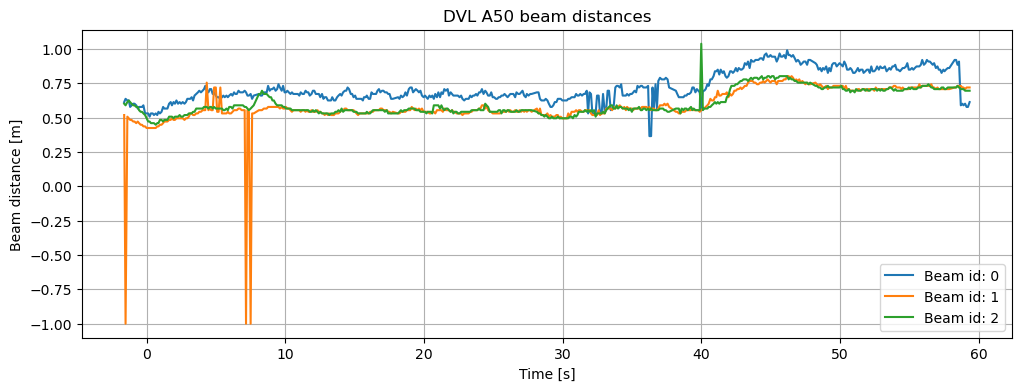

In [507]:
plt.figure(figsize=(12, 4))

# --- DVL-A50 ---
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.0.distance"].values, label="Beam id: 0")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.1.distance"].values, label="Beam id: 1")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.2.distance"].values, label="Beam id: 2")

plt.title("DVL A50 beam distances")
plt.xlabel("Time [s]")
plt.ylabel("Beam distance [m]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# INS Linear velocity 
# TODO: Fjern konstant g!

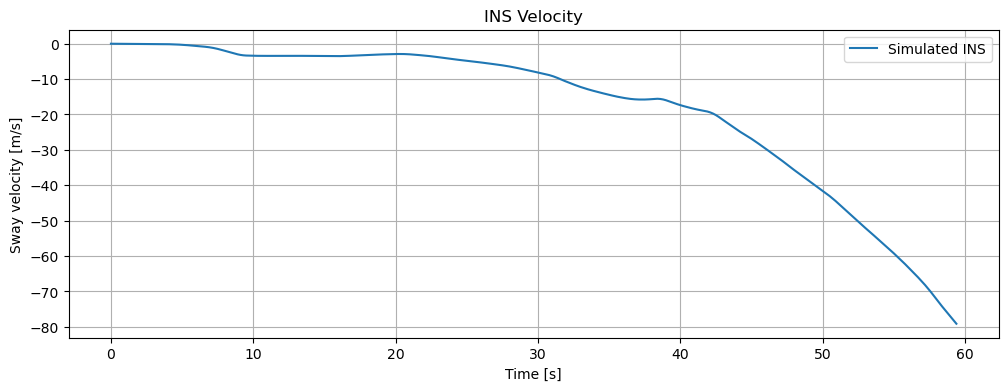

In [529]:
plt.figure(figsize=(12, 4))

plt.plot(sim_ins["t"].values, -sim_ins["pose.north"].values, label="Simulated INS")

# plt.plot(nucleus_ins["t"].values, nucleus_ins["velocityNed.x"].values, label="Nucleus 1000 INS")

# plt.plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values-0.1, label="Simulation Ground Truth")


plt.title("INS Velocity")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# Net Distance

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


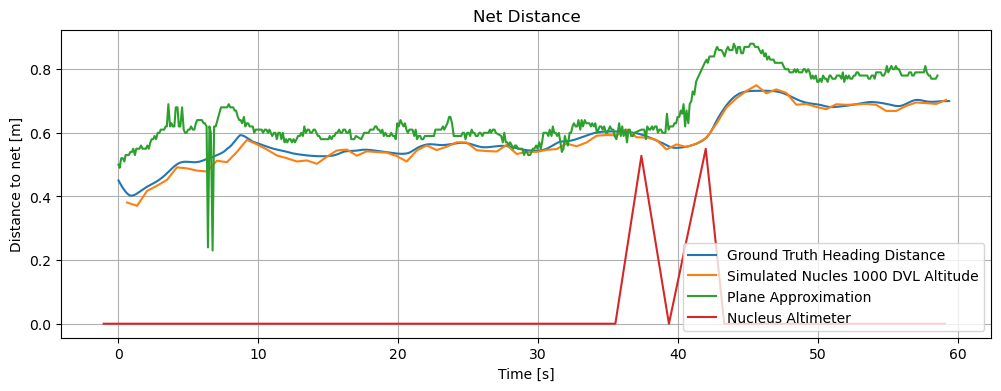

In [503]:
heading_dist_gt = get_profiler_data(SIM_BAG_PATH, "/heading_distance_ground_truth")
plane_approximation = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/navigation/plane_approximation")
normalize_time(plane_approximation)


plt.figure(figsize=(12, 4))
plt.plot(heading_dist_gt["time"], heading_dist_gt["ranges"], label="Ground Truth Heading Distance")
plt.plot(sim_dvl["t"].values, sim_dvl["altitude"].values, label="Simulated Nucles 1000 DVL Altitude")
# plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["altitude"].values, label="DVL-A50 Altitude")

plt.plot(plane_approximation["t"].values, plane_approximation["NetDistance"].values, label="Plane Approximation")


plt.plot(nucleus_alitmeter["t"].values, nucleus_alitmeter["altimeter_distance"].values, label="Nucleus Altimeter")



plt.title("Net Distance")
plt.xlabel("Time [s]")
plt.ylabel("Distance to net [m]")
plt.legend()
plt.grid()

Liten avvik i starten er mest sannsynlig på grunn av vinkelen på roven. Siden dvl har en vinkel på 4 beams.

# Pressure

In [504]:
# Read csv
real_depth_df = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/depth_temperature")
sim_depth_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/pressure")
sim_depth_gt_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")

set_t0(real_depth_df, t0_real)
set_t0(sim_depth_df, t0_sim)
set_t0(sim_depth_gt_df, t0_sim)



RHO = 1031 # [kg/m^3]
g = 9.81

# get array of data
depth_real = real_depth_df["depth"].values
depth_sim = (sim_depth_df["fluid_pressure"].values) / (RHO * g)
sim_depth_gt = sim_depth_gt_df["pose.pose.position.z"].values

"""

# PLOT
plt.figure(figsize=(12, 4))
plt.title("Depth Sensor Comparison")
plt.plot(real_depth_df["t"].values, depth_real, label="Real Depth Data")
plt.plot(sim_depth_df["t"].values, depth_sim, label="Simulated Depth Data")
plt.plot(sim_depth_gt_df["t"].values, sim_depth_gt, label="Simulation Ground Truth")



ins_depth = nucleus_ins["positionFrame.z"].values
# ins_depth -= ins_depth.mean()
# ins_depth += depth_real.mean()

plt.plot(nucleus_ins["t"].values, ins_depth, label="Nucleus 1000 INS")

plt.xlabel("Time [s]")
plt.ylabel("Depth [m]")
plt.legend()
plt.grid()
# plt.ylim(-0.35, -0.1)
plt.show()

"""

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


'\n\n# PLOT\nplt.figure(figsize=(12, 4))\nplt.title("Depth Sensor Comparison")\nplt.plot(real_depth_df["t"].values, depth_real, label="Real Depth Data")\nplt.plot(sim_depth_df["t"].values, depth_sim, label="Simulated Depth Data")\nplt.plot(sim_depth_gt_df["t"].values, sim_depth_gt, label="Simulation Ground Truth")\n\n\n\nins_depth = nucleus_ins["positionFrame.z"].values\n# ins_depth -= ins_depth.mean()\n# ins_depth += depth_real.mean()\n\nplt.plot(nucleus_ins["t"].values, ins_depth, label="Nucleus 1000 INS")\n\nplt.xlabel("Time [s]")\nplt.ylabel("Depth [m]")\nplt.legend()\nplt.grid()\n# plt.ylim(-0.35, -0.1)\nplt.show()\n\n'

{'rmse': 0.023453320606163452, 'corr': 0.561123047130853, 'mean_error': -0.0020866692660226954, 'kurtosis_diff': 0.036698541107269556}
{'rmse': 0.033410027472986645, 'corr': 0.4142724778191395, 'mean_error': 0.0019573737397702872, 'kurtosis_diff': 0.7917995094128369}
{'rmse': 0.02488852381197597, 'corr': 0.195487092625699, 'mean_error': -0.0006134559268764302, 'kurtosis_diff': 2.9126005795704204}


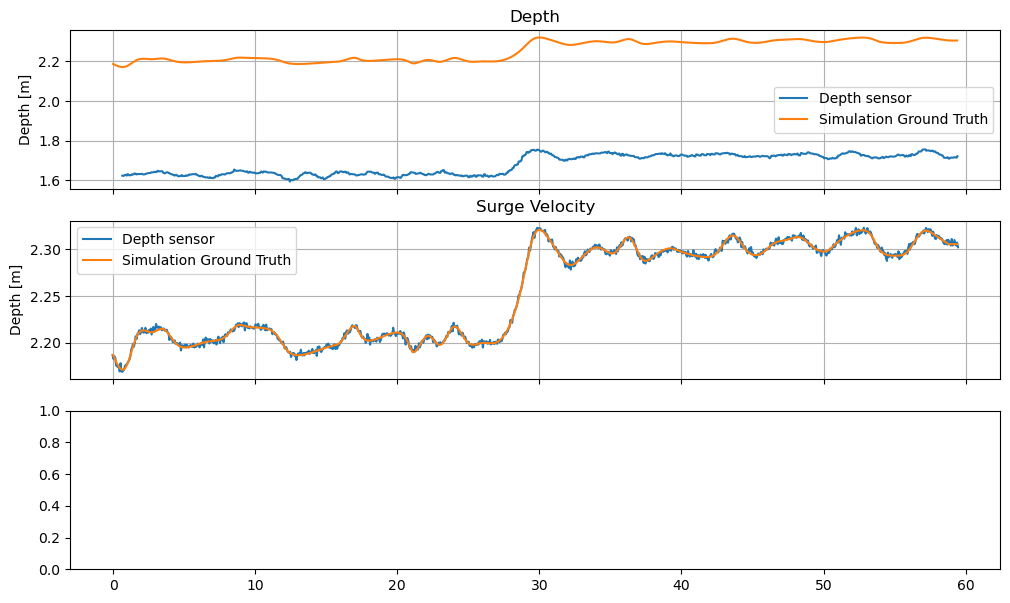

In [505]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(real_depth_df["t"].values, real_depth_df["depth"].values, label="Depth sensor")
axes[0].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
axes[0].set_title("Depth")
axes[0].set_ylabel("Depth [m]")
axes[0].legend()
axes[0].grid(True)


axes[1].plot(sim_depth_df["t"].values, depth_sim, label="Depth sensor")
axes[1].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
axes[1].set_title("Surge Velocity")
axes[1].set_ylabel("Depth [m]")
axes[1].legend()
axes[1].grid(True)


comp_surge = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.x"].values,
                        nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values)

comp_sway = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.y"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)

comp_heave = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.z"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)

print(comp_surge)
print(comp_sway)
print(comp_heave)